# Métodos avanzados para tratamiento de outliers.
## Inteligencia Artificial y Aprendizaje Automático I.
## *Chocobares Juan Cruz - Formenti Agustín*

PREGUNTAS AL FINAL.

In [1]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Paso 1 — Carga y Exploración del Dataset

In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

# Completar el path con el nombre del archivo
df = pd.read_csv(f"{path}/creditcard.csv")
df.head()

Path to dataset files: C:\Users\juanc\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(f"Shape: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nValores nulos:\n{df.isnull().sum()}")

Shape: (284807, 31)

Tipos de datos:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Valores nulos:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dty

In [4]:
# Distribución de clases
conteo = df["Class"].value_counts()
proporcion = df["Class"].value_counts(normalize=True) * 100

print("Conteo absoluto:")
print(conteo)
print("\nProporción (%):")
print(proporcion.round(3))

Conteo absoluto:
Class
0    284315
1       492
Name: count, dtype: int64

Proporción (%):
Class
0    99.827
1     0.173
Name: proportion, dtype: float64


In [5]:
# Estadísticas descriptivas de Amount y Time
df[["Amount", "Time"]].describe()

,Amount,Time
count,284807.000000,284807.000000
mean,88.349619,94813.859575
std,250.120109,47488.145955
min,0.000000,0.000000
25%,5.600000,54201.500000
50%,22.000000,84692.000000
75%,77.165000,139320.500000
max,25691.160000,172792.000000


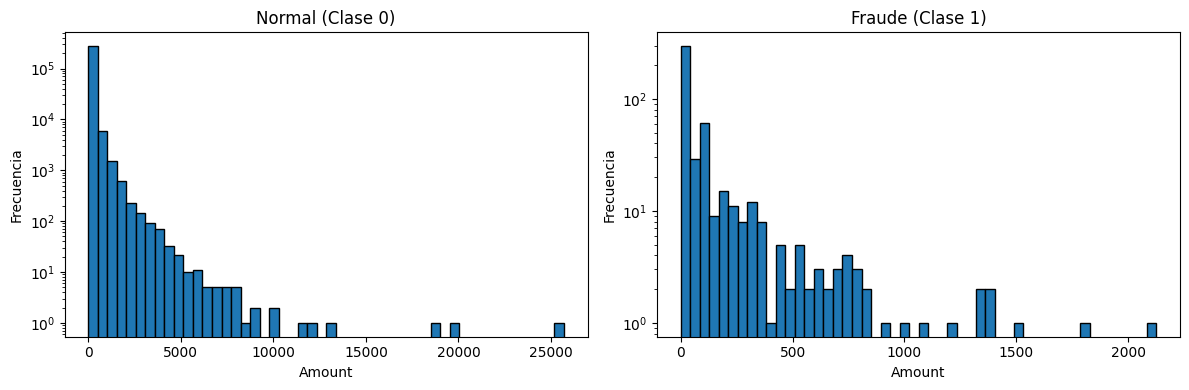

In [6]:
# Visualización 1: distribución de Amount por clase
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, clase, titulo in zip(axes, [0, 1], ["Normal (Clase 0)", "Fraude (Clase 1)"]):
    subset = df[df["Class"] == clase]["Amount"]
    ax.hist(subset, bins=50, edgecolor="black")
    ax.set_title(titulo)
    ax.set_xlabel("Amount")
    ax.set_ylabel("Frecuencia")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

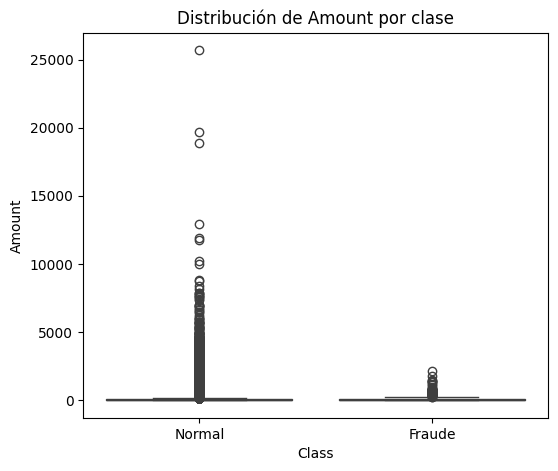

In [7]:
# Boxplot de Amount por clase
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="Class", y="Amount")
plt.xticks([0, 1], ["Normal", "Fraude"])
plt.title("Distribución de Amount por clase")
plt.show()

## Paso 2 — Detección de Outliers
Aplicamos tres métodos para identificar outliers en Amount y en las
variables V1-V28: IQR, Z-Score e Isolation Forest. El objetivo es
analizar si los outliers detectados coinciden con las transacciones
fraudulentas.

In [9]:
# Detección de outliers con IQR sobre Amount
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR:.2f}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")

# Máscara de outliers
mask_iqr = (df["Amount"] < limite_inferior) | (df["Amount"] > limite_superior)

print(f"\nTotal outliers detectados por IQR: {mask_iqr.sum()}")
print(f"De esos, cuántos son fraudes: {df[mask_iqr]['Class'].sum()}")
print(f"Porcentaje de fraudes entre los outliers IQR: {df[mask_iqr]['Class'].mean()*100:.2f}%")
print(f"\nPara referencia, % fraudes en el dataset completo: {df['Class'].mean()*100:.3f}%")

Q1: 5.6, Q3: 77.16499999999999, IQR: 71.56
Límite inferior: -101.75
Límite superior: 184.51

Total outliers detectados por IQR: 31904
De esos, cuántos son fraudes: 91
Porcentaje de fraudes entre los outliers IQR: 0.29%

Para referencia, % fraudes en el dataset completo: 0.173%


In [10]:
import numpy as np
from scipy import stats

# Detección de outliers con Z-Score sobre Amount
z_scores = np.abs(stats.zscore(df["Amount"]))
umbral = 3

mask_zscore = z_scores > umbral

print(f"Total outliers detectados por Z-Score (|z| > 3): {mask_zscore.sum()}")
print(f"De esos, cuántos son fraudes: {df[mask_zscore]['Class'].sum()}")
print(f"Porcentaje de fraudes entre outliers Z-Score: {df[mask_zscore]['Class'].mean()*100:.2f}%")

Total outliers detectados por Z-Score (|z| > 3): 4076
De esos, cuántos son fraudes: 11
Porcentaje de fraudes entre outliers Z-Score: 0.27%


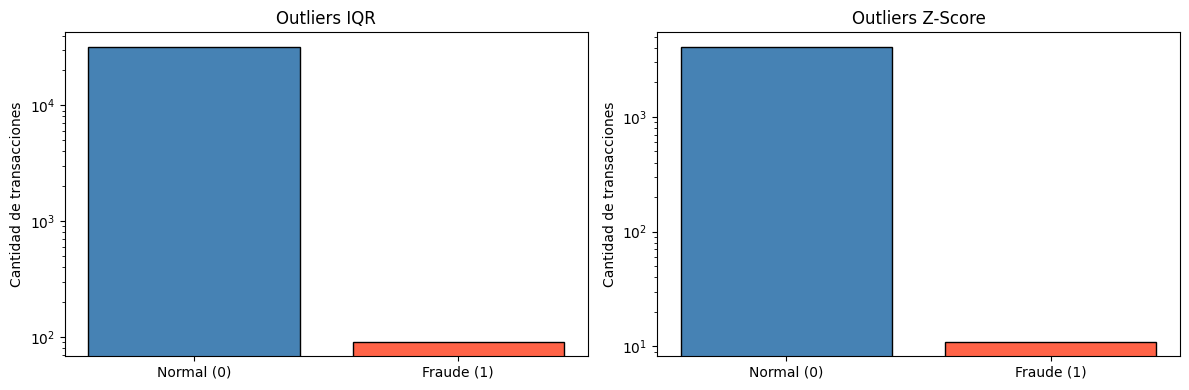

In [11]:
# Comparación visual: IQR vs Z-Score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, mask, titulo in zip(axes,
                             [mask_iqr, mask_zscore],
                             ["Outliers IQR", "Outliers Z-Score"]):
    conteo = df[mask]["Class"].value_counts()
    ax.bar(["Normal (0)", "Fraude (1)"],
           [conteo.get(0, 0), conteo.get(1, 0)],
           color=["steelblue", "tomato"],
           edgecolor="black")
    ax.set_title(titulo)
    ax.set_ylabel("Cantidad de transacciones")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

### Reporte de Clasificación — Isolation Forest

Isolation Forest

In [12]:
from sklearn.ensemble import IsolationForest

# Usamos todas las variables numéricas excepto Class
features = [col for col in df.columns if col != "Class"]
X = df[features]

# contamination = proporción esperada de anomalías
# Usamos el porcentaje real de fraudes en el dataset
contaminacion = df["Class"].mean()
print(f"Contaminación configurada: {contaminacion:.4f}")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=contaminacion,
    random_state=42,
    n_jobs=-1  # usa todos los cores disponibles
)

# -1 = anomalía, 1 = normal
df["iso_pred"] = iso_forest.fit_predict(X)

# Convertir a 0/1 para comparar con Class
df["iso_pred_bin"] = (df["iso_pred"] == -1).astype(int)

Contaminación configurada: 0.0017


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

print("Reporte de clasificación - Isolation Forest:")
print(classification_report(df["Class"], df["iso_pred_bin"],
                             target_names=["Normal", "Fraude"]))

Reporte de clasificación - Isolation Forest:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    284315
      Fraude       0.26      0.26      0.26       492

    accuracy                           1.00    284807
   macro avg       0.63      0.63      0.63    284807
weighted avg       1.00      1.00      1.00    284807



In [14]:
# Cuántos fraudes reales captura Isolation Forest
fraudes_capturados = df[(df["iso_pred_bin"] == 1) & (df["Class"] == 1)].shape[0]
total_fraudes = df["Class"].sum()

print(f"Fraudes capturados: {fraudes_capturados} de {total_fraudes}")
print(f"Recall de fraudes: {fraudes_capturados/total_fraudes*100:.1f}%")

Fraudes capturados: 126 de 492
Recall de fraudes: 25.6%


## Paso 3 — Estrategias de Tratamiento
Dado que los outliers en Amount no corresponden a fraudes, aplicamos
dos estrategias para reducir su impacto sin eliminar ninguna fila:
winsorización y transformación logarítmica.

In [15]:
# Estrategia A: Winsorización de Amount

p1 = df["Amount"].quantile(0.01)
p99 = df["Amount"].quantile(0.99)

print(f"Percentil 1: {p1:.2f}")
print(f"Percentil 99: {p99:.2f}")

df["Amount_winsorized"] = df["Amount"].clip(lower=p1, upper=p99)

print(f"\nAmount original  - max: {df['Amount'].max():.2f}, std: {df['Amount'].std():.2f}")
print(f"Amount winsorizado - max: {df['Amount_winsorized'].max():.2f}, std: {df['Amount_winsorized'].std():.2f}")

Percentil 1: 0.12
Percentil 99: 1017.97

Amount original  - max: 25691.16, std: 250.12
Amount winsorizado - max: 1017.97, std: 159.28


In [16]:
# Estrategia B: Transformación logarítmica
# log1p porque hay transacciones con Amount = 0

df["Amount_log"] = np.log1p(df["Amount"])

print(f"Amount log - max: {df['Amount_log'].max():.2f}, std: {df['Amount_log'].std():.2f}")

Amount log - max: 10.15, std: 1.66


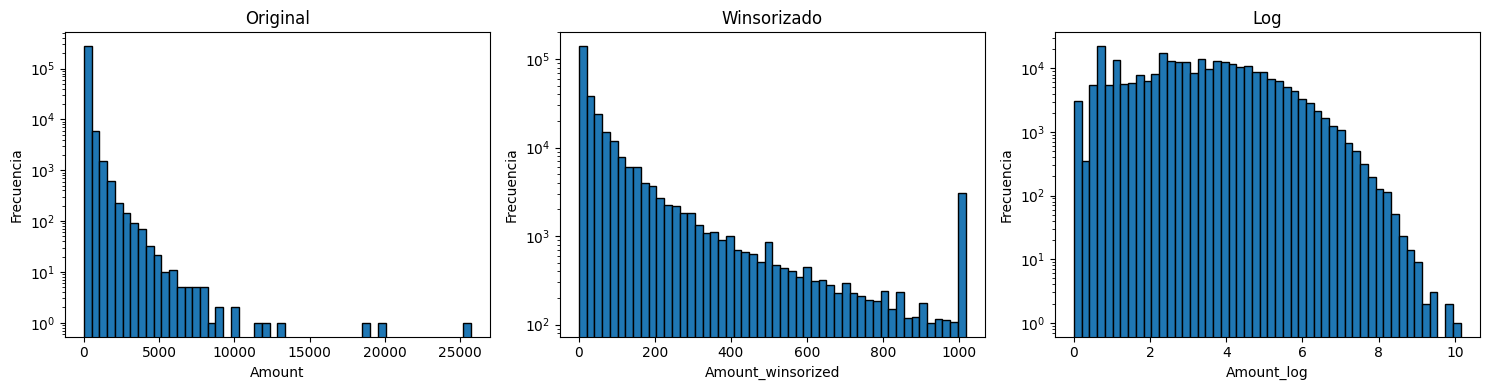

In [17]:
# Visualización comparativa de las tres versiones
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, titulo in zip(axes,
                            ["Amount", "Amount_winsorized", "Amount_log"],
                            ["Original", "Winsorizado", "Log"]):
    ax.hist(df[col], bins=50, edgecolor="black")
    ax.set_title(titulo)
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

### Reportes de Clasificación — Comparación de Estrategias

## Paso 4 — Comparación de Estrategias
Entrenamos una Regresión Logística con cada versión de Amount para
evaluar si las transformaciones mejoran la detección de fraudes.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Features comunes para los tres experimentos
features_base = [f"V{i}" for i in range(1, 29)]

resultados = {}

for nombre, col_amount in [("Original", "Amount"),
                            ("Winsorizado", "Amount_winsorized"),
                            ("Log", "Amount_log")]:

    X = df[features_base + [col_amount]]
    y = df["Class"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    modelo = LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )
    modelo.fit(X_train_scaled, y_train)

    y_pred = modelo.predict(X_test_scaled)
    resultados[nombre] = classification_report(y_test, y_pred, output_dict=True)

    print(f"\n--- {nombre} ---")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Fraude"]))


--- Original ---
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
      Fraude       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


--- Winsorizado ---
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
      Fraude       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


--- Log ---
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
      Fraude       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.0

In [19]:
# Tabla comparativa de métricas para clase Fraude
metricas = ["precision", "recall", "f1-score"]

print("Comparación de métricas para clase Fraude:")
print(f"{'Estrategia':<15} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-" * 50)

for nombre, reporte in resultados.items():
    p = reporte["1"]["precision"]
    r = reporte["1"]["recall"]
    f = reporte["1"]["f1-score"]
    print(f"{nombre:<15} {p:>10.3f} {r:>10.3f} {f:>10.3f}")

Comparación de métricas para clase Fraude:
Estrategia       Precision     Recall   F1-Score
--------------------------------------------------
Original             0.059      0.918      0.110
Winsorizado          0.058      0.918      0.109
Log                  0.058      0.918      0.109


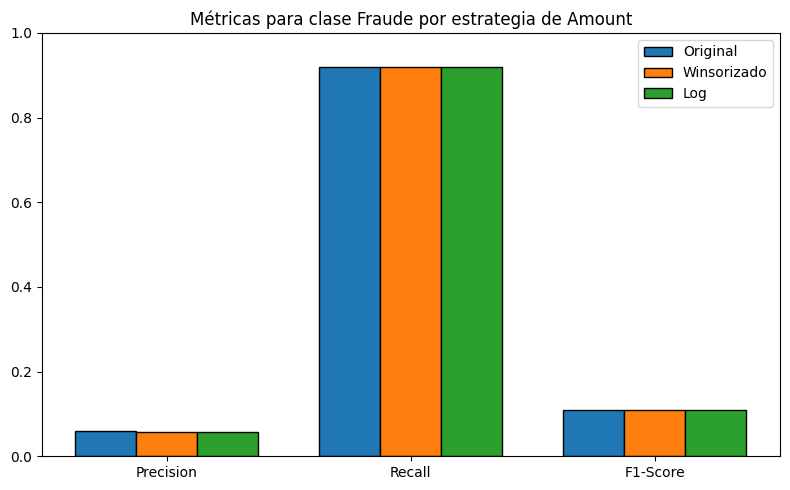

In [20]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(metricas))
ancho = 0.25

for i, (nombre, reporte) in enumerate(resultados.items()):
    valores = [reporte["1"][m] for m in metricas]
    ax.bar(x + i * ancho, valores, width=ancho, label=nombre, edgecolor="black")

ax.set_xticks(x + ancho)
ax.set_xticklabels(["Precision", "Recall", "F1-Score"])
ax.set_ylim(0, 1)
ax.set_title("Métricas para clase Fraude por estrategia de Amount")
ax.legend()
plt.tight_layout()
plt.show()

## Preguntas de Reflexión

### 1. ¿Por qué no deberíamos eliminar outliers en este dataset?

En este dataset los outliers en Amount no coinciden con los fraudes.
IQR detectó 31.904 outliers pero solo 91 eran fraudes (0,29%), apenas
por encima del 0,17% del dataset completo. Eliminar esos registros
significaría perder el 18,5% de los fraudes reales (91 de 492) sin
ningún beneficio para el modelo. En detección de fraudes el outlier
no es ruido sino la señal de interés: eliminarlo destruye el objetivo
del problema.

### 2. ¿Qué pasa si aplicamos Isolation Forest para detectar fraudes? ¿Es mejor que el modelo de clasificación?

Isolation Forest capturó 126 de 492 fraudes (recall 25,6%) con una
precisión de 0,26. La Regresión Logística supervisada alcanzó un
recall de 0,92 sobre la misma clase. Isolation Forest es un algoritmo
no supervisado: no utiliza las etiquetas durante el entrenamiento,
solo identifica puntos raros en el espacio de features. El problema
es que las variables V1-V28 provienen de PCA y muchos fraudes no son
los puntos más aislados en ese espacio transformado. Cuando se
dispone de etiquetas, un modelo supervisado es claramente superior
para esta tarea.

### 3. ¿Qué estrategia de manejo de outliers en Amount mejora más la detección de fraudes?

Ninguna de las tres estrategias produjo diferencias medibles:
precision ~0,06, recall ~0,92 y F1 ~0,11 en los tres casos. Esto se
explica porque las variables V1-V28 dominan la predicción y Amount
tiene un peso relativo muy bajo en el modelo. La transformación de
Amount podría tener más impacto en modelos donde Amount fuera una
feature más determinante, pero en este dataset no es el caso.